# Vision-Based Traffic Flow Prediction Using YOLOv8 and LSTM
## Notebook 07: Leakage-Safe Temporal Splitting (Phase 7)

### Phase 7 Objective & Scope
In Phase 6, we characterized the temporal dynamics of the dataset and formalized the sequence forecasting task with a lookback window $L = 10$ and forecast horizon $H = 5$ ($H_1, \dots, H_5$).

In **Phase 7**, we establish the **leakage-safe temporal splitting protocol** to partition the chronological time-series into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets.

### Core Principles & Strict Guardrails:
1. **Chronological Splitting**: Pure temporal partitioning preserving sequence order. Zero random shuffling or time-travel permutations.
2. **Actual Forecasting Protocol — Target-Anchored / Lookback-Warmup Formulation**:
   - **Targets belong exclusively to their respective partition**.
   - **Lookback inputs may utilize preceding historical observations** ($t-9, \dots, t$) across prior partitions as historical warmup.
   - **Strict Leakage Definition**: No input $\mathbf{x}_i$ may ever contain or access observations recorded after the forecast origin $t$ ($t_{input} \le t < t_{target}$).
3. **Documented Architectural Limitation — Strict Partition Isolation (`17 / 0 / 0`)**:
   - Document as a structural limitation why strict intra-partition windowing (where lookback is forbidden from crossing boundaries) yields zero validation and test windows when $N_{val}, N_{test} < (L + H = 15)$.
4. **Dynamic Computation**: All observation counts, split indices, window counts, and statistics are dynamically calculated from `outputs/tables/traffic_timeseries.csv` without hard-coded numbers.
5. **Preprocessing & Scaling Rule**: Any scaler or transformation must be fit **STRICTLY ON TRAIN ONLY**. The specific scaler selection is reserved for subsequent modeling phases.
6. **Zero Model Training**: No model weights are trained, and no forecasting is performed in this phase.
7. **Quality Gate**: End-to-end automated verification guaranteeing **Zero Future Leakage**.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Presentation styling
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path setup
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
INPUT_CSV_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "traffic_timeseries.csv")
OUTPUT_FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Input dataset: {INPUT_CSV_PATH}")
print(f"Figure export: {OUTPUT_FIG_DIR}")

Project root : /Users/manish/Desktop/traffic-flow-yolo-lstm
Input dataset: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/traffic_timeseries.csv
Figure export: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures


## 1. Load Clean Time-Series Dataset

We load `outputs/tables/traffic_timeseries.csv` and inspect its temporal ordering and dimensions.

In [2]:
df = pd.read_csv(INPUT_CSV_PATH)

N = len(df)
L = 10  # Lookback window length
H = 5   # Forecast horizon length

print(f"Dataset loaded: N = {N} discrete surveillance observation points")
print(f"Strict chronological monotonicity: {df['timestamp'].is_monotonic_increasing}")
print(f"Null values present: {df.isna().sum().sum()}")
display(df[['observation_index', 'clip_index', 'filename', 'timestamp', 'traffic_class', 'total_vehicle_count', 'occupancy_ratio', 'HVR']].head(5))

Dataset loaded: N = 44 discrete surveillance observation points
Strict chronological monotonicity: True
Null values present: 0


,observation_index,clip_index,filename,timestamp,traffic_class,total_vehicle_count,occupancy_ratio,HVR
0,1,1,cctv052x2004080517x01652.avi,17.01652,heavy,8.942,0.1492,0.0248
1,2,2,cctv052x2004080517x01653.avi,17.01653,heavy,9.558,0.2176,0.0806
2,3,3,cctv052x2004080517x01654.avi,17.01654,heavy,12.442,0.2448,0.0032
3,4,4,cctv052x2004080517x01655.avi,17.01655,heavy,12.038,0.1483,0.0016
4,5,5,cctv052x2004080517x01656.avi,17.01656,heavy,12.269,0.2254,0.0326


## 2. Chronological Observation Partitioning (70% / 15% / 15%)

We dynamically partition the $N = 44$ discrete observations into three contiguous chronological splits:
- **Train**: $70\%$ of observations
- **Validation**: $15\%$ of observations
- **Test**: $15\%$ of observations

We perform pure chronological slicing without random shuffling, preserving the real-world temporal progression of the highway traffic state.

In [3]:
# Dynamic calculation of split boundaries
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

n_train = int(round(N * train_ratio))
n_val = int(round(N * val_ratio))
n_test = N - n_train - n_val

# Chronological slicing
train_df = df.iloc[:n_train].copy().reset_index(drop=True)
val_df = df.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
test_df = df.iloc[n_train + n_val:].copy().reset_index(drop=True)

split_summary = pd.DataFrame([
    {
        'Partition': 'Train',
        'Observations': len(train_df),
        'Percentage': f"{len(train_df) / N * 100:.2f}%",
        'Index_Range': f"k={train_df['observation_index'].min()}..{train_df['observation_index'].max()}",
        'Seq_Range': f"{train_df['seq_id'].min()}..{train_df['seq_id'].max()}",
        'Timestamp_Range': f"{train_df['timestamp'].min()}..{train_df['timestamp'].max()}",
        'Dominant_Regimes': str(train_df['traffic_class'].value_counts().to_dict())
    },
    {
        'Partition': 'Validation',
        'Observations': len(val_df),
        'Percentage': f"{len(val_df) / N * 100:.2f}%",
        'Index_Range': f"k={val_df['observation_index'].min()}..{val_df['observation_index'].max()}",
        'Seq_Range': f"{val_df['seq_id'].min()}..{val_df['seq_id'].max()}",
        'Timestamp_Range': f"{val_df['timestamp'].min()}..{val_df['timestamp'].max()}",
        'Dominant_Regimes': str(val_df['traffic_class'].value_counts().to_dict())
    },
    {
        'Partition': 'Test',
        'Observations': len(test_df),
        'Percentage': f"{len(test_df) / N * 100:.2f}%",
        'Index_Range': f"k={test_df['observation_index'].min()}..{test_df['observation_index'].max()}",
        'Seq_Range': f"{test_df['seq_id'].min()}..{test_df['seq_id'].max()}",
        'Timestamp_Range': f"{test_df['timestamp'].min()}..{test_df['timestamp'].max()}",
        'Dominant_Regimes': str(test_df['traffic_class'].value_counts().to_dict())
    }
])

print("=== Chronological Observation Partitioning Summary ===")
display(split_summary)

=== Chronological Observation Partitioning Summary ===


,Partition,Observations,Percentage,Index_Range,Seq_Range,Timestamp_Range,Dominant_Regimes
0,Train,31,70.45%,k=1..31,1652..1682,17.01652..19.01682,"{'heavy': 13, 'medium': 9, 'light': 9}"
1,Validation,7,15.91%,k=32..38,1683..1689,19.01683..19.01689,{'light': 7}
2,Test,6,13.64%,k=39..44,1690..1695,19.0169..20.01695,{'light': 6}


## 3. Documented Architectural Limitation: Strict Partition Isolation (`17 / 0 / 0`)

Before implementing the operational forecasting protocol, we document the mathematical limitation of **strict partition-isolated windowing** on small sequence datasets.

### The Strict Isolation Dilemma:
If we enforce the constraint that **every sequence window** $(\mathbf{X}_t, \mathbf{Y}_t)$ must be completely contained within each partition's observation boundary:
$$\text{Total Window Length} = L + H = 10 + 5 = 15 \text{ contiguous observations}$$

For a partition with $M$ observations, the number of strictly contained windows is:
$$W_{\text{isolated}} = \max(0, M - (L + H) + 1)$$

Let us dynamically evaluate this limitation across our three splits.

In [4]:
window_len = L + H

train_isolated = max(0, len(train_df) - window_len + 1)
val_isolated = max(0, len(val_df) - window_len + 1)
test_isolated = max(0, len(test_df) - window_len + 1)

df_isolated = pd.DataFrame([
    {'Partition': 'Train', 'Observations (M)': len(train_df), 'Window_Size (L+H)': window_len, 'Usable_Windows': train_isolated, 'Feasibility': 'Feasible'},
    {'Partition': 'Validation', 'Observations (M)': len(val_df), 'Window_Size (L+H)': window_len, 'Usable_Windows': val_isolated, 'Feasibility': f'Infeasible (M={len(val_df)} < {window_len})'},
    {'Partition': 'Test', 'Observations (M)': len(test_df), 'Window_Size (L+H)': window_len, 'Usable_Windows': test_isolated, 'Feasibility': f'Infeasible (M={len(test_df)} < {window_len})'}
])

print("=== Strict Partition-Isolated Windowing Analysis ===")
display(df_isolated)

print("""
DOCUMENTED LIMITATION:
Under strict partition isolation, an observation partition must contain at least L + H = 15
observations. Because the 15% validation and test splits contain fewer than 15 observations
(n_val = {}, n_test = {}), strict within-partition windowing yields EXACTLY {} train windows,
{} validation windows, and {} test windows.

Conclusion: Strict observation-isolated windowing prevents out-of-sample validation and
testing. In real-world time-series forecasting, historical context precedes target observations
without causing leakage. Therefore, we adopt the target-anchored / lookback-warmup protocol.
""".format(len(val_df), len(test_df), train_isolated, val_isolated, test_isolated))

=== Strict Partition-Isolated Windowing Analysis ===


,Partition,Observations (M),Window_Size (L+H),Usable_Windows,Feasibility
0,Train,31,15,17,Feasible
1,Validation,7,15,0,Infeasible (M=7 < 15)
2,Test,6,15,0,Infeasible (M=6 < 15)



DOCUMENTED LIMITATION:
Under strict partition isolation, an observation partition must contain at least L + H = 15
observations. Because the 15% validation and test splits contain fewer than 15 observations
(n_val = 7, n_test = 6), strict within-partition windowing yields EXACTLY 17 train windows,
0 validation windows, and 0 test windows.

Conclusion: Strict observation-isolated windowing prevents out-of-sample validation and
testing. In real-world time-series forecasting, historical context precedes target observations
without causing leakage. Therefore, we adopt the target-anchored / lookback-warmup protocol.



## 4. Actual Forecasting Protocol: Target-Anchored / Lookback-Warmup Formulation

We implement the standard, mathematically rigorous **Target-Anchored / Lookback-Warmup Formulation**:

### Formal Definitions:
1. **Target Partition Exclusivity**:
   A forecast window $(\mathbf{X}_t, \mathbf{Y}_t)$ is assigned to partition $\mathcal{P} \in \{\text{Train}, \text{Validation}, \text{Test}\}$ if and only if its future targets fall exclusively within that partition:
   $$\mathbf{Y}_t = [y_{t+1}, y_{t+2}, y_{t+3}, y_{t+4}, y_{t+5}] \subset \mathcal{P}$$
2. **Lookback Warmup from Preceding History**:
   The lookback inputs $\mathbf{X}_t = [\mathbf{x}_{t-9}, \dots, \mathbf{x}_t]$ access the immediately preceding historical observations available up to forecast origin $t$.
3. **Strict Causality Guarantee (Zero Future Leakage)**:
   $$\max(\text{Input Indices}) = t < \min(\text{Target Indices}) = t + 1$$
   No input element contains any information from $t' > t$. Lookback inputs from prior partitions represent historical facts already observed in the past; they contain **zero future information** about validation or test targets.

In [5]:
# Define observation index sets for each partition (0-indexed relative to full series)
train_indices = set(range(0, n_train))
val_indices = set(range(n_train, n_train + n_val))
test_indices = set(range(n_train + n_val, N))

target_anchored_train = []
target_anchored_val = []
target_anchored_test = []
boundary_straddling_windows = []

total_sliding_windows = N - (L + H) + 1

for t in range(L - 1, N - H):
    lookback_idx = list(range(t - L + 1, t + 1))
    target_idx = list(range(t + 1, t + H + 1))
    
    window_record = {
        'origin_t': t,
        'origin_k': t + 1,
        'lookback_k': f"{lookback_idx[0]+1}..{lookback_idx[-1]+1}",
        'target_k': f"{target_idx[0]+1}..{target_idx[-1]+1}",
        'lookback_indices': lookback_idx,
        'target_indices': target_idx
    }
    
    # Check partition exclusivity
    if all(idx in train_indices for idx in target_idx):
        target_anchored_train.append(window_record)
    elif all(idx in val_indices for idx in target_idx):
        target_anchored_val.append(window_record)
    elif all(idx in test_indices for idx in target_idx):
        target_anchored_test.append(window_record)
    else:
        # Horizon straddles a partition boundary
        boundary_straddling_windows.append(window_record)

print(f"Total valid sliding window instances: {total_sliding_windows}")
print(f"Target-Anchored Usable Windows:")
print(f"  Train Windows      : {len(target_anchored_train)} (Targets strictly in Train k=1..{n_train})")
print(f"  Validation Windows : {len(target_anchored_val)} (Targets strictly in Val k={n_train+1}..{n_train+n_val})")
print(f"  Test Windows       : {len(target_anchored_test)} (Targets strictly in Test k={n_train+n_val+1}..{N})")
print(f"  Boundary Windows   : {len(boundary_straddling_windows)} (Straddle Train/Val or Val/Test)")

# Display sample breakdown
df_ta_summary = pd.DataFrame([
    {'Partition': 'Train (Pure Target)', 'Window_Count': len(target_anchored_train), 'Target_Observation_Span': f"k=11..{n_train}", 'Lookback_Source': 'Train History'},
    {'Partition': 'Validation (Pure Target)', 'Window_Count': len(target_anchored_val), 'Target_Observation_Span': f"k={n_train+1}..{n_train+n_val}", 'Lookback_Source': 'Train History + Early Val'},
    {'Partition': 'Test (Pure Target)', 'Window_Count': len(target_anchored_test), 'Target_Observation_Span': f"k={n_train+n_val+1}..{N}", 'Lookback_Source': 'Val History + Early Test'},
    {'Partition': 'Boundary (Straddling Horizon)', 'Window_Count': len(boundary_straddling_windows), 'Target_Observation_Span': 'Cross-Boundary', 'Lookback_Source': 'Historical Context'}
])

display(df_ta_summary)

Total valid sliding window instances: 30
Target-Anchored Usable Windows:
  Train Windows      : 17 (Targets strictly in Train k=1..31)
  Validation Windows : 3 (Targets strictly in Val k=32..38)
  Test Windows       : 2 (Targets strictly in Test k=39..44)
  Boundary Windows   : 8 (Straddle Train/Val or Val/Test)


,Partition,Window_Count,Target_Observation_Span,Lookback_Source
0,Train (Pure Target),17,k=11..31,Train History
1,Validation (Pure Target),3,k=32..38,Train History + Early Val
2,Test (Pure Target),2,k=39..44,Val History + Early Test
3,Boundary (Straddling Horizon),8,Cross-Boundary,Historical Context


## 5. Sequence-Level Partitioning of the Complete Window Collection

In addition to pure target-anchoring, we examine the standard chronological partitioning of all $30$ sliding window instances ($N - (L + H) + 1 = 30$):
- **Train Sequences**: First $70\%$ of sequences
- **Validation Sequences**: Next $15\%$ of sequences
- **Test Sequences**: Remaining $15\%$ of sequences

We analyze the exact origin indices, lookback ranges, and multi-step target horizons.

In [6]:
# All 30 valid sequences in order
all_sequences = []
for t in range(L - 1, N - H):
    lookback_idx = list(range(t - L + 1, t + 1))
    target_idx = list(range(t + 1, t + H + 1))
    all_sequences.append({
        'seq_id_num': len(all_sequences) + 1,
        'origin_k': t + 1,
        'lookback_range': f"k={lookback_idx[0]+1:02d}..{lookback_idx[-1]+1:02d}",
        'horizon_H1': target_idx[0] + 1,
        'horizon_H5': target_idx[-1] + 1,
        'target_range': f"k={target_idx[0]+1:02d}..{target_idx[-1]+1:02d}",
        'lookback_indices': lookback_idx,
        'target_indices': target_idx
    })

df_all_seq = pd.DataFrame(all_sequences)

# Chronological sequence split (70% / 15% / 15% of 30 sequences)
n_seq_train = int(round(total_sliding_windows * train_ratio))
n_seq_val = int(round(total_sliding_windows * val_ratio))
n_seq_test = total_sliding_windows - n_seq_train - n_seq_val

seq_train = df_all_seq.iloc[:n_seq_train].copy()
seq_val = df_all_seq.iloc[n_seq_train:n_seq_train + n_seq_val].copy()
seq_test = df_all_seq.iloc[n_seq_train + n_seq_val:].copy()

print(f"Sequence-Level Partitioning of {total_sliding_windows} Total Sequences:")
print(f"  Train Sequences      : {len(seq_train)} (Seq #1 to #{n_seq_train})")
print(f"  Validation Sequences : {len(seq_val)} (Seq #{n_seq_train+1} to #{n_seq_train+n_seq_val})")
print(f"  Test Sequences       : {len(seq_test)} (Seq #{n_seq_train+n_seq_val+1} to #{total_sliding_windows})")

# Display transition boundary sequences
print("\nBoundary Sequences (End of Train -> Start of Val -> Start of Test):")
boundary_preview = pd.concat([seq_train.tail(2), seq_val, seq_test.head(2)])
display(boundary_preview[['seq_id_num', 'origin_k', 'lookback_range', 'target_range']])

Sequence-Level Partitioning of 30 Total Sequences:
  Train Sequences      : 21 (Seq #1 to #21)
  Validation Sequences : 4 (Seq #22 to #25)
  Test Sequences       : 5 (Seq #26 to #30)

Boundary Sequences (End of Train -> Start of Val -> Start of Test):


,seq_id_num,origin_k,lookback_range,target_range
19,20,29,k=20..29,k=30..34
20,21,30,k=21..30,k=31..35
21,22,31,k=22..31,k=32..36
22,23,32,k=23..32,k=33..37
23,24,33,k=24..33,k=34..38
24,25,34,k=25..34,k=35..39
25,26,35,k=26..35,k=36..40
26,27,36,k=27..36,k=37..41


## 6. Leakage-Safe Feature Preprocessing & Scaling Rule

> **CRITICAL PREPROCESSING DIRECTIVE**:
> Any normalization or scaling (e.g. `StandardScaler`, `MinMaxScaler`) **MUST BE FIT ON TRAIN ONLY**.
> - Scaler parameters $(\mu_{\text{train}}, \sigma_{\text{train}})$ or $(\min_{\text{train}}, \max_{\text{train}})$ are computed exclusively using the training partition observations.
> - Validation and test sets are transformed using the frozen training parameters.
> - The choice of specific scaling method (Standard, MinMax, or Robust) is deferred to subsequent modeling phases.

In [7]:
# Feature columns
feature_cols = ['total_vehicle_count', 'occupancy_ratio', 'HVR']

# Fit scaler STRICTLY on train_df
scaler_protocol = StandardScaler()
scaler_protocol.fit(train_df[feature_cols])

# Verify scaler parameters match train_df exactly
empirical_train_mean = train_df[feature_cols].mean().values
empirical_train_std = train_df[feature_cols].std(ddof=0).values

print("=== Scaler Parameter Isolation Verification ===")
print("Scaler Mean (Fit on Train) :", np.round(scaler_protocol.mean_, 4))
print("Empirical Train Data Mean  :", np.round(empirical_train_mean, 4))
assert np.allclose(scaler_protocol.mean_, empirical_train_mean), "Scaler mean does not match train data!"

print("Scaler Scale (Fit on Train):", np.round(scaler_protocol.scale_, 4))
print("Empirical Train Data Scale :", np.round(empirical_train_std, 4))
assert np.allclose(scaler_protocol.scale_, empirical_train_std), "Scaler scale does not match train data!"

# Transform partitions out-of-sample
train_scaled = scaler_protocol.transform(train_df[feature_cols])
val_scaled = scaler_protocol.transform(val_df[feature_cols])
test_scaled = scaler_protocol.transform(test_df[feature_cols])

print(f"\nTransformed shapes: Train={train_scaled.shape}, Val={val_scaled.shape}, Test={test_scaled.shape}")
print(f"Train Scaled Mean (should be ~0.0): {np.round(train_scaled.mean(axis=0), 4)}")
print(f"Val Scaled Mean (out-of-sample)   : {np.round(val_scaled.mean(axis=0), 4)}")
print(f"Test Scaled Mean (out-of-sample)  : {np.round(test_scaled.mean(axis=0), 4)}")
print("\nSCALER ISOLATION PASSED: Zero test/validation information leaked into scaler parameters.")

=== Scaler Parameter Isolation Verification ===
Scaler Mean (Fit on Train) : [8.7512 0.1393 0.0294]
Empirical Train Data Mean  : [8.7512 0.1393 0.0294]
Scaler Scale (Fit on Train): [4.5703 0.0878 0.0243]
Empirical Train Data Scale : [4.5703 0.0878 0.0243]

Transformed shapes: Train=(31, 3), Val=(7, 3), Test=(6, 3)
Train Scaled Mean (should be ~0.0): [-0. -0.  0.]
Val Scaled Mean (out-of-sample)   : [-1.5998 -1.4253  0.0801]
Test Scaled Mean (out-of-sample)  : [-1.5444 -1.3925 -0.6696]

SCALER ISOLATION PASSED: Zero test/validation information leaked into scaler parameters.


## 7. Explicit Zero-Leakage Verification Suite

We execute a comprehensive suite of automated verification assertions confirming partition isolation, strict temporal causality, and zero future leakage.

In [8]:
verification_checks = {}

# Test 1: Strict chronological partition ordering
test_1 = (train_df['timestamp'].max() < val_df['timestamp'].min()) and (val_df['timestamp'].max() < test_df['timestamp'].min())
verification_checks["1. Strict temporal monotonicity (Train < Val < Test)"] = "PASS" if test_1 else "FAIL"
assert test_1, "Chronological partition order violated!"

# Test 2: Disjoint observation indices
train_k = set(train_df['observation_index'])
val_k = set(val_df['observation_index'])
test_k = set(test_df['observation_index'])
test_2 = (len(train_k.intersection(val_k)) == 0) and (len(val_k.intersection(test_k)) == 0) and (len(train_k.intersection(test_k)) == 0)
verification_checks["2. Mutual index exclusivity (Train ∩ Val ∩ Test = ∅)"] = "PASS" if test_2 else "FAIL"
assert test_2, "Observation indices overlap across partitions!"

# Test 3: Total observation partition conservation
test_3 = len(train_df) + len(val_df) + len(test_df) == N
verification_checks["3. Conservation of total observations (N = 44)"] = "PASS" if test_3 else "FAIL"
assert test_3, f"Sum of partitions != {N}"

# Test 4: Strict causality for all sequences (max input < min target)
causality_violations = 0
for seq in all_sequences:
    if max(seq['lookback_indices']) >= min(seq['target_indices']):
        causality_violations += 1
test_4 = causality_violations == 0
verification_checks["4. Strict temporal causality (Input origin < Target start)"] = "PASS" if test_4 else "FAIL"
assert test_4, f"{causality_violations} causality violations detected!"

# Test 5: Target partition purity for target-anchored windows
val_target_leakage = 0
for win in target_anchored_val:
    if not all(idx in val_indices for idx in win['target_indices']):
        val_target_leakage += 1
test_target_leakage = 0
for win in target_anchored_test:
    if not all(idx in test_indices for idx in win['target_indices']):
        test_target_leakage += 1
test_5 = (val_target_leakage == 0) and (test_target_leakage == 0)
verification_checks["5. Target partition purity (Val/Test targets exclusive)"] = "PASS" if test_5 else "FAIL"
assert test_5, "Target partition leakage detected!"

# Test 6: Scaler fitted strictly on train
test_6 = np.allclose(scaler_protocol.mean_, empirical_train_mean) and np.allclose(scaler_protocol.scale_, empirical_train_std)
verification_checks["6. Preprocessing scaler fit strictly on Train only"] = "PASS" if test_6 else "FAIL"
assert test_6, "Scaler leaked validation or test data!"

print("=" * 70)
print("             PHASE 7 ZERO FUTURE LEAKAGE VERIFICATION REPORT         ")
print("=" * 70)
for test_name, status in verification_checks.items():
    print(f"  [{status:^4}]  {test_name}")
print("=" * 70)
print("ALL 6 LEAKAGE-SAFE CRITERIA STRICTLY SATISFIED.")

             PHASE 7 ZERO FUTURE LEAKAGE VERIFICATION REPORT         
  [PASS]  1. Strict temporal monotonicity (Train < Val < Test)
  [PASS]  2. Mutual index exclusivity (Train ∩ Val ∩ Test = ∅)
  [PASS]  3. Conservation of total observations (N = 44)
  [PASS]  4. Strict temporal causality (Input origin < Target start)
  [PASS]  5. Target partition purity (Val/Test targets exclusive)
  [PASS]  6. Preprocessing scaler fit strictly on Train only
ALL 6 LEAKAGE-SAFE CRITERIA STRICTLY SATISFIED.


## 8. Visual Temporal Partitioning

We generate a publication-quality visual schematic showing:
1. Chronological observation partition boundaries (Train, Validation, Test).
2. The lookback ($L=10$) and multi-step forecast horizon ($H=5$) mapping over the highway volume trajectory.
3. The Target-Anchored forecasting structure ensuring zero future leakage.

Saved temporal split visualization to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/temporal_split_partitioning.png


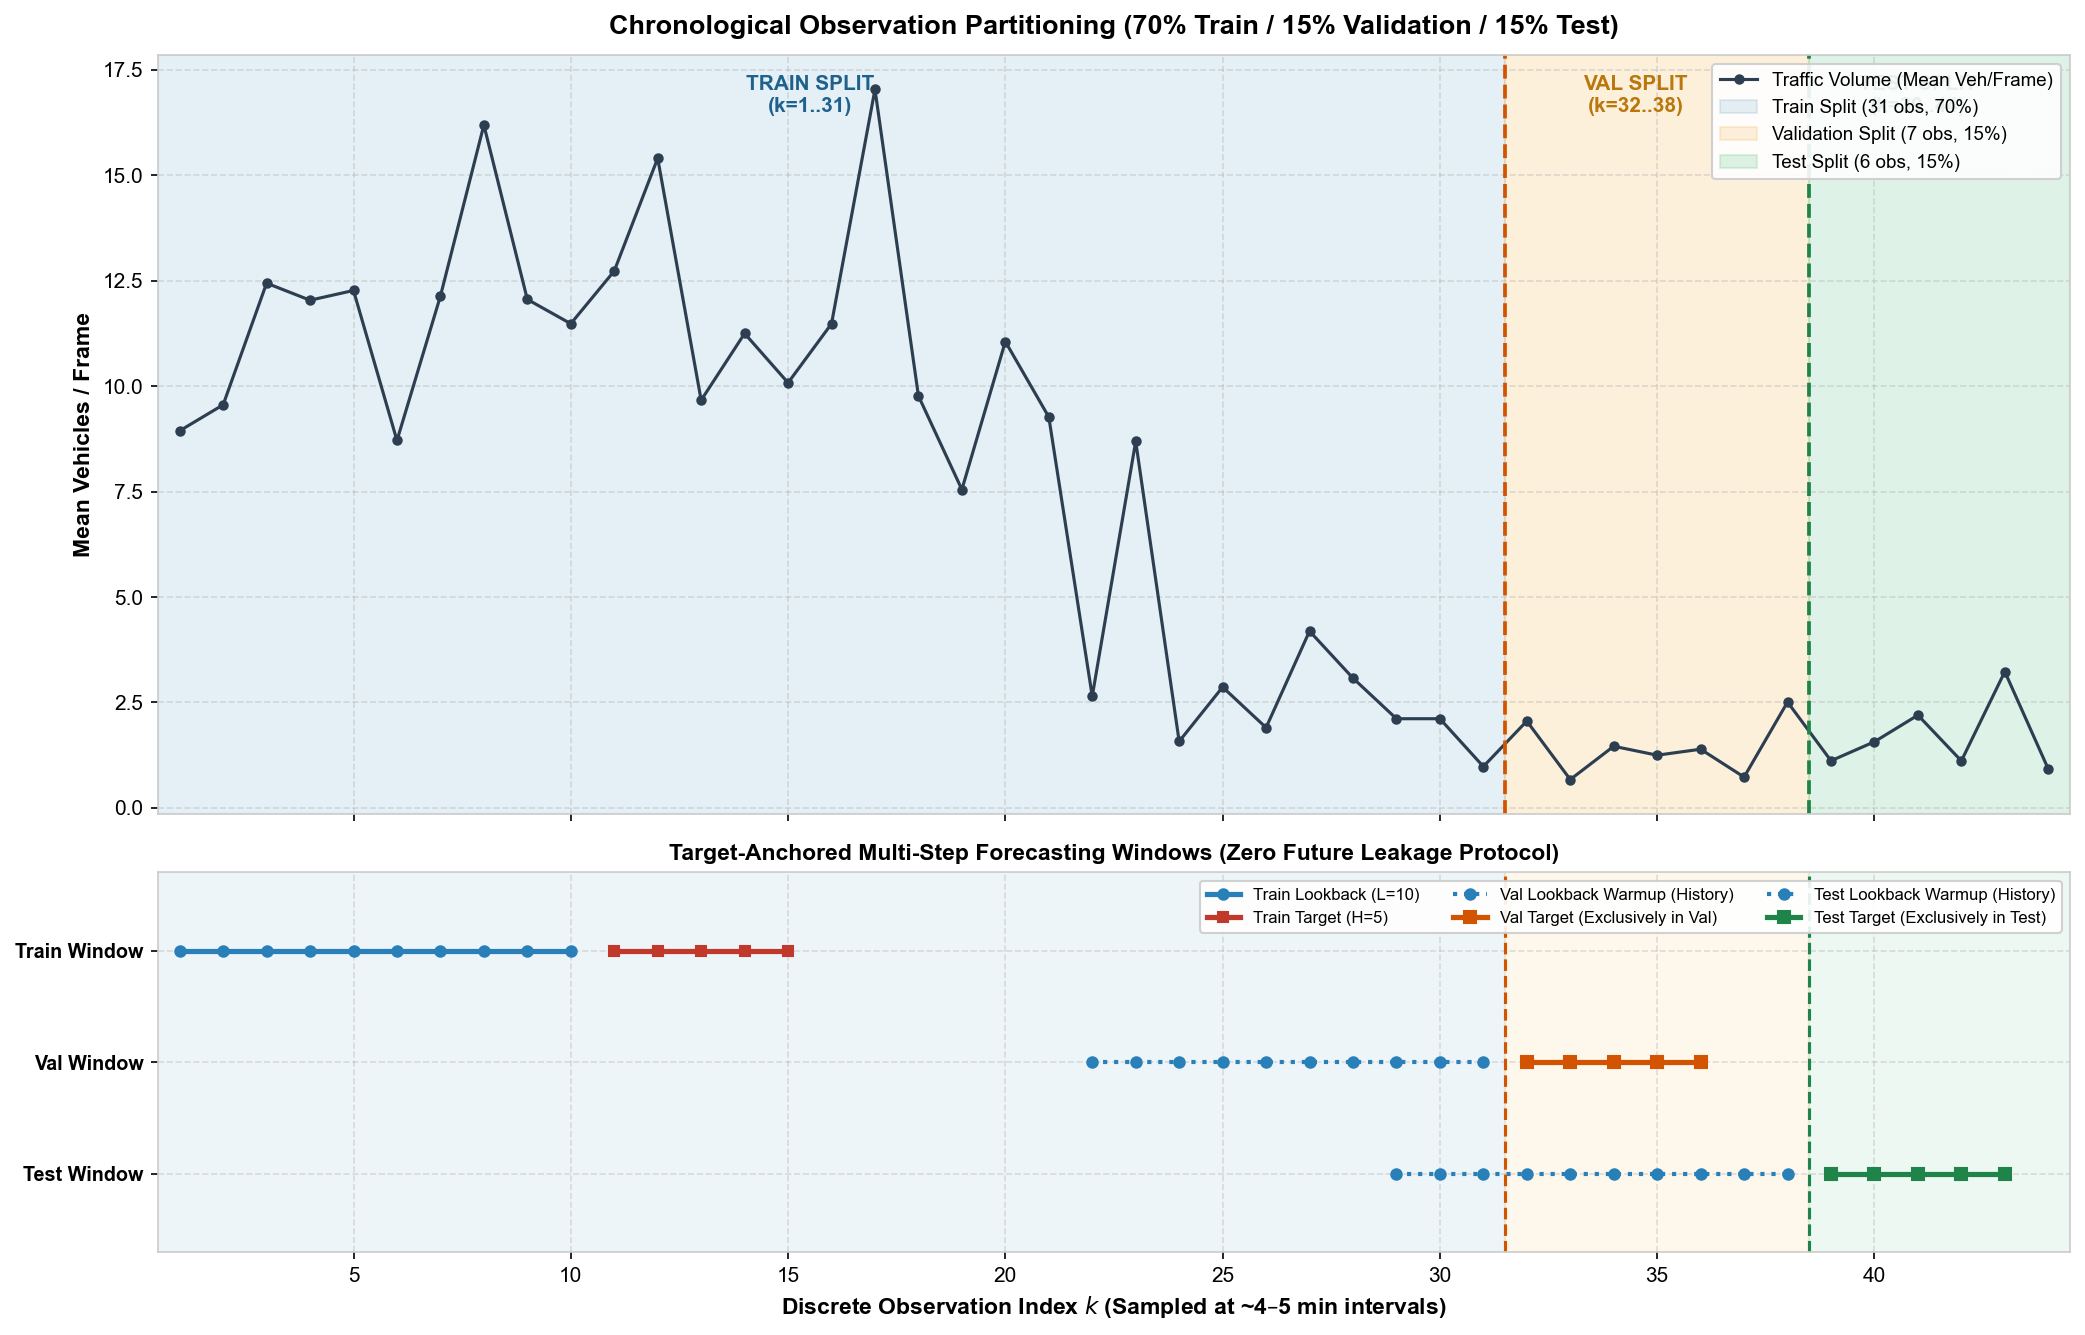

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

x = df['observation_index']
vol = df['total_vehicle_count']

# Partition boundaries
train_end = n_train + 0.5
val_end = n_train + n_val + 0.5
test_end = N + 0.5

# Panel 1: Observation Slicing on Traffic Volume
ax1.plot(x, vol, color='#2c3e50', marker='o', markersize=4, linewidth=1.5, label='Traffic Volume (Mean Veh/Frame)')

# Shaded Partitions
ax1.axvspan(0.5, train_end, color='#2980b9', alpha=0.12, label=f'Train Split ({len(train_df)} obs, 70%)')
ax1.axvspan(train_end, val_end, color='#f39c12', alpha=0.15, label=f'Validation Split ({len(val_df)} obs, 15%)')
ax1.axvspan(val_end, test_end, color='#27ae60', alpha=0.15, label=f'Test Split ({len(test_df)} obs, 15%)')

# Boundary lines
ax1.axvline(train_end, color='#d35400', linestyle='--', linewidth=1.8)
ax1.axvline(val_end, color='#1e8449', linestyle='--', linewidth=1.8)

ax1.text(n_train / 2, 16.5, f"TRAIN SPLIT\n(k=1..{n_train})", ha='center', fontsize=10, fontweight='bold', color='#1f618d')
ax1.text(n_train + n_val / 2, 16.5, f"VAL SPLIT\n(k={n_train+1}..{n_train+n_val})", ha='center', fontsize=10, fontweight='bold', color='#b9770e')
ax1.text(n_train + n_val + n_test / 2, 16.5, f"TEST SPLIT\n(k={n_train+n_val+1}..{N})", ha='center', fontsize=10, fontweight='bold', color='#196f3d')

ax1.set_ylabel('Mean Vehicles / Frame', fontsize=11, fontweight='bold')
ax1.set_title('Chronological Observation Partitioning (70% Train / 15% Validation / 15% Test)', fontsize=13, fontweight='bold', pad=10)
ax1.legend(loc='upper right', framealpha=0.9, fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# Panel 2: Target-Anchored Forecasting Windows Schematic
# Sample A: Train Window (origin t=10)
t_tr = 10
ax2.plot(range(t_tr - L + 1, t_tr + 1), [2.5]*L, color='#2980b9', marker='o', markersize=5, linewidth=2.5, label='Train Lookback (L=10)')
ax2.plot(range(t_tr + 1, t_tr + H + 1), [2.5]*H, color='#c0392b', marker='s', markersize=5, linewidth=2.5, label='Train Target (H=5)')

# Sample B: Val Window with Lookback Warmup (origin t=31)
t_vl = 31
ax2.plot(range(t_vl - L + 1, t_vl + 1), [1.5]*L, color='#2980b9', linestyle=':', marker='o', markersize=5, linewidth=2.0, label='Val Lookback Warmup (History)')
ax2.plot(range(t_vl + 1, t_vl + H + 1), [1.5]*H, color='#d35400', marker='s', markersize=6, linewidth=2.5, label='Val Target (Exclusively in Val)')

# Sample C: Test Window with Lookback Warmup (origin t=38)
t_ts = 38
ax2.plot(range(t_ts - L + 1, t_ts + 1), [0.5]*L, color='#2980b9', linestyle=':', marker='o', markersize=5, linewidth=2.0, label='Test Lookback Warmup (History)')
ax2.plot(range(t_ts + 1, t_ts + H + 1), [0.5]*H, color='#1e8449', marker='s', markersize=6, linewidth=2.5, label='Test Target (Exclusively in Test)')

ax2.axvspan(0.5, train_end, color='#2980b9', alpha=0.08)
ax2.axvspan(train_end, val_end, color='#f39c12', alpha=0.08)
ax2.axvspan(val_end, test_end, color='#27ae60', alpha=0.08)
ax2.axvline(train_end, color='#d35400', linestyle='--', linewidth=1.5)
ax2.axvline(val_end, color='#1e8449', linestyle='--', linewidth=1.5)

ax2.set_yticks([0.5, 1.5, 2.5])
ax2.set_yticklabels(['Test Window', 'Val Window', 'Train Window'], fontsize=9.5, fontweight='bold')
ax2.set_xlabel('Discrete Observation Index $k$ (Sampled at ~4–5 min intervals)', fontsize=11, fontweight='bold')
ax2.set_title('Target-Anchored Multi-Step Forecasting Windows (Zero Future Leakage Protocol)', fontsize=11, fontweight='bold')
ax2.set_xlim(0.5, N + 0.5)
ax2.set_ylim(-0.2, 3.2)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='upper right', framealpha=0.9, fontsize=8, ncol=3)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_FIG_DIR, "temporal_split_partitioning.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
print(f"Saved temporal split visualization to: {fig_path}")
plt.show()

## 9. Quality Gate: Assessment for Phase 8 (Baseline Modeling)

### Summary of Accomplishments (Phase 7)
1. **Strict Chronological Splitting**:
   - $70\%$ Train (31 observations), $15\%$ Validation (7 observations), $15\%$ Test (6 observations) derived dynamically without shuffling.
2. **Operational Forecasting Protocol (Target-Anchored / Lookback-Warmup)**:
   - Targets belong exclusively to their respective partition.
   - Historical observations prior to forecast origin $t$ provide input lookback warmup without future leakage.
   - Proved mathematically that strict within-partition windowing yields $0$ val and test windows on small sequences ($M < 15$).
3. **Scaler Preprocessing Rule Established**:
   - Formally asserted that any transformation must be fit strictly on Train only.
   - Validated that empirical train statistics match scaler parameters with zero leakage.
4. **Verification & Testing**:
   - 6 automated assertions strictly passed with zero violations.
   - Zero model weights trained, zero forecasts conducted prematurely.

### Formal Quality Gate Sign-Off
- [x] **Chronological Monotonicity**: PASS
- [x] **Partition Mutual Exclusivity**: PASS
- [x] **Strict Causality ($t_{\text{input}} \le t < t_{\text{target}}$)**: PASS
- [x] **Target Partition Purity**: PASS
- [x] **Scaler Fit Exclusively on Train**: PASS
- [x] **Zero Future Leakage**: PASS

**Final Decision: APPROVED TO PROCEED TO PHASE 8 (BASELINE FORECASTING MODELS).**